# Feedback stabilization and the overdamping paradox

*Introduction to Control and Machine Learning · Part I: Control · Notebook 05*

> **Central question.** *How can a control computed from the current state make a system converge to equilibrium?*

| | |
|---|---|
| **Estimated reading time** (an estimate, not a measurement with students) | CORE ≈ 50–60 min · DEEPER LOOK ≈ 10 min more |
| **Execution time** | a few seconds |
| **Exercises** | 5 exercises, ≈ 60–100 min |
| **Prerequisites** | [notebook 01](01_control_fundamentals.ipynb) (open and closed loop; the overdamping paradox); [notebook 03](03_observability_duality_adjoints.ipynb) (observability inequality, §5) |
| **Source** | Slides `CML_slides_20250520.pdf`, PDF pp. 121–132, 16, 23–24, 286 (see the Source map at the end) |
| **Notation** | `notation.md` §1. **Local overloads:** $L$ is a feedback matrix, $u=Lx$; $k$ is a damping coefficient; $\omega$ is a decay rate and $\gamma$ a contraction factor (pp. 122–126) |

**How to read this notebook.** `CORE` sections give the complete story. `DEEPER LOOK` sections contain proofs of secondary facts, finer comparisons and optional checks. `RESEARCH WINDOW` sections point to advanced material from the slides. Both kinds of section can be skipped, and no CORE cell depends on them. (Cells carry the same labels as machine-readable tags.)

> **First pass through this notebook.**
> *Essential:* the CORE sections §§1–5 with their laboratories (Figures 1–3 and the E2 check), Exercises 1–2.
> *Deeper study:* the DEEPER LOOK §7 (the estimate behind the proof), Exercises 3–4.
> *Research-oriented:* Exercise 5, on how sharp the guaranteed rate is.

**Learning objectives.** After this notebook you should be able to

1. formulate the stabilization problem for $x'=Ax+Bu$ with a linear feedback $u=Lx$, and explain why such a feedback cannot reach the equilibrium in finite time;
2. prove that $u=-B^*x$ stabilizes a controllable system with skew-adjoint $A$, using the energy identity and the observability inequality of notebook 03;
3. explain the overdamping paradox through the characteristic roots of the closed loop, and why velocity feedback alone cannot beat critical damping;
4. use full-state feedback to place the closed-loop eigenvalues, and weigh its benefit against larger gains;
5. distinguish controllability from stabilizability, using the example E2.

## Where are we?
`CORE`

> **Recap.** [Notebook 01](01_control_fundamentals.ipynb): an *open-loop* control $u=u(t)$ is computed in advance; a *closed-loop* or feedback control $u=F(x(t))$ is computed from the current state, and it is robust to disturbances. Damping $x_1''+kx_1'+x_1=0$ is the oscillator E1 under the feedback $u=-kx_2$, and its decay rate is largest at $k=2$: *more damping can slow the return to rest*.
> [Notebook 03](03_observability_duality_adjoints.ipynb), §5: if $(A,B)$ is controllable, the adjoint system is **observable**, meaning that $\int_0^T|B^*\varphi|^2dt\ge c_0|\varphi(0)|^2$ for some $c_0>0$.

Notebooks 02–04 built open-loop controls: functions of time, computed from the model before anything happens. **Feedback reacts to the current state instead.** Notebook 01 *observed* the overdamping paradox. Here we place it inside a theory: when does feedback stabilize, how fast, and what limits the speed?

## 1. The stabilization problem
`CORE`

The controls built so far are *open loop*. In practice it is often more useful to have closed-loop or feedback controls, whose value is related in real time to the state itself (PDF p. 121).

**A conservative system.** Assume that $A$ is skew-adjoint, $A^*=-A$, as for the oscillator E1. Then $\langle Ax,x\rangle=0$, and without control the energy is conserved (pp. 121–122):
$$
\frac{d}{dt}|x(t)|^2=2\langle Ax,x\rangle=0,\qquad |x(t)|=|x^0|\ \text{ for all }t\ge0 .
$$

> **Definition (exponential stabilization by linear feedback, p. 122).** A matrix $L\in\mathbb R^{m\times n}$ **stabilizes** the system if every solution of the closed loop
> $$x'=(A+BL)\,x,\qquad x(0)=x^0,$$
> satisfies $|x(t)|\le c\,e^{-\omega t}|x^0|$ for some constants $c>0$ and $\omega>0$ independent of $x^0$.

**Three notions not to blur** *(pedagogical addition)*. The closed loop is *stable* if its solutions stay bounded, *asymptotically stable* if they tend to $0$, and *exponentially stable* if the estimate of the definition holds. For a linear system in finite dimension, asymptotic and exponential stability coincide, and both hold if and only if every eigenvalue of $A+BL$ has negative real part. The **optimal decay rate** is set by the spectrum: the estimate holds for every $\omega<-\max\operatorname{Re}\lambda(A+BL)$ and for no larger $\omega$. A proof of exponential stability may deliver a much smaller $\omega$ than the optimal one (§2, Figure 1).

**What linear feedback cannot do (p. 123).** One cannot expect more than exponential decay. If a solution of $x'=(A+BL)x$ reached $x(T)=0$, then, by uniqueness of solutions with final datum $0$ at $t=T$, it would be identically zero, so $x^0=0$. *An autonomous linear feedback never brings a nonzero state exactly to rest.* This is a statement about this class of feedback laws, not about all possible controls: the open-loop controls of notebooks 02–04 do reach the equilibrium exactly at time $T$.

## 2. The feedback $u=-B^*x$
`CORE`

> **Theorem 1 (stabilization of conservative systems; p. 123).**
> *Assumptions:* $A^*=-A$, and $(A,B)$ satisfies the Kalman rank condition.
> *Conclusion:* $L=-B^*$ stabilizes the system: the solutions of
> $$x'=Ax-BB^*x,\qquad x(0)=x^0,$$
> decay exponentially, $|x(t)|^2\le c\,e^{-\omega t}|x^0|^2$, with explicit constants given below.
> *Interpretation:* the feedback removes energy exactly through the observed component $B^*x$, and observability guarantees that this cannot stay small for long.

The proof has three steps. Only the third, the key inequality, uses controllability.

**Step 1: the energy identity (p. 124).** With $L=-B^*$, and using $\langle Ax,x\rangle=0$,
$$
\frac12\frac{d}{dt}|x(t)|^2=-\langle BB^*x,x\rangle=-|B^*x(t)|^2\le0,
\qquad\text{so}\qquad
|x(T)|^2-|x(0)|^2=-2\int_0^T|B^*x|^2\,dt .
\tag{E}
$$

**Step 2: a contraction over one period implies exponential decay (pp. 124–126).** Suppose there are $T>0$ and $c>2$ such that
$$
|x(0)|^2\le c\int_0^T|B^*x|^2\,dt\qquad\text{for every solution of the closed loop}.
\tag{K}
$$
Then (E) gives $|x(T)|^2\le\gamma|x(0)|^2$ with $\gamma=1-2/c<1$. The closed loop is autonomous, so the same holds on every interval $[jT,(j+1)T]$, and $|x(jT)|^2\le\gamma^j|x^0|^2$. For $t=jT+\delta$ with $0\le\delta<T$, the norm is non-increasing, so
$$
|x(t)|^2\le|x(jT)|^2\le\gamma^{\,j}|x^0|^2\le\frac1\gamma\,e^{-\omega t}|x^0|^2,\qquad\omega=\frac{|\ln\gamma|}{T}.
$$
These are the constants of p. 126: $c'=1/\gamma$ and $\omega=|\ln\gamma|/T$, for the squared norm.

**Step 3: the key inequality (K) from observability (pp. 126–128).** Split the closed-loop solution as $x=\varphi+y$, where
$$
\varphi'=A\varphi,\ \varphi(0)=x^0,\qquad\qquad y'=Ay-BB^*x,\ y(0)=0 .
$$
The free solution $\varphi$ solves the adjoint system of notebook 03, because $-\varphi'=A^*\varphi$ when $A^*=-A$, except that its datum is given at $t=0$ (p. 127). By observability (notebook 03, §5),
$$
|x^0|^2=|\varphi(0)|^2\le\frac1{c_0}\int_0^T|B^*\varphi|^2\,dt .
$$
Since $\varphi=x-y$, we have $\int|B^*\varphi|^2\le2\int|B^*x|^2+2\int|B^*y|^2$. It remains to bound $y$, which is driven only by $B^*x$:
$$
\int_0^T|B^*y|^2\,dt\le K_T\int_0^T|B^*x|^2\,dt,\qquad K_T=\tfrac12\|B\|^4T^2
$$
(§7). Combining the three inequalities gives (K) with
$$
c=\frac{2}{c_0}\big(1+K_T\big)=\frac{2}{c_0}\Big(1+\tfrac12\|B\|^4T^2\Big). \qquad\square
$$

*Why $c>2$.* By (E), $2\int_0^T|B^*x|^2\le|x^0|^2$, so any constant in (K) satisfies $c\ge2$, and enlarging it gives $c>2$: no large horizon is needed. The proof gives *some* rate, not the best one; the laboratory compares the two.

In [1]:
import sys
from pathlib import Path


def find_repository_root():
    # The shared code lives in CML_notebooks/src/. Search this folder and its parents.
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "src" / "control_utils.py").exists():
            return folder
    raise FileNotFoundError(
        "Could not find src/control_utils.py in this folder or any parent folder.\n"
        "Run this notebook from inside the complete CML_notebooks repository "
        "(for example from CML_notebooks/notebooks/), after installing requirements.txt.\n"
        "See README.md, section 'Installation'.")


sys.path.insert(0, str(find_repository_root()))

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

from src.control_utils import (harmonic_oscillator, damped_oscillator, near_uncontrollable_system, kalman_rank,
                               gramian, observability_constant, spectral_abscissa, simulate)
from src.plotting_utils import apply_style, COLORS

apply_style()
np.set_printoptions(precision=5, suppress=True)

**Laboratory: the theorem for E1.** For the oscillator, $u=-B^*x=-x_2$. We compare three quantities over one period $T$:

- the *exact* contraction factor $\gamma_{\rm exact}=\max_{x^0}|x(T)|^2/|x^0|^2=\|e^{(A-BB^*)T}\|^2$;
- the factor $\gamma=1-2/c$ guaranteed by the proof, with $c=\tfrac{2}{c_0}(1+\tfrac12\|B\|^4T^2)$ and $c_0$ the observability constant of notebook 03;
- the decay rate of $|x(t)|^2$ that each one implies, against the true rate.

By (E), $|x(T)|^2=|x^0|^2-2\int_0^T|B^*x|^2$ exactly, so $\gamma_{\rm exact}=1-2\lambda_{\min}(W_T)$, with $W_T=\int_0^Te^{(A-BB^*)^*t}BB^*e^{(A-BB^*)t}dt$. The code checks this identity as well.

observability constant c_0(T)         = 1.5708
proof: gamma = 1 - 2/c                = 0.7353   -> rate of |x|^2 >= 0.0979
exact contraction over one period     = 6.8970e-02   (1 - 2 lambda_min(W_T) = 6.8970e-02)
true asymptotic rate of |x|^2         = 1.0000


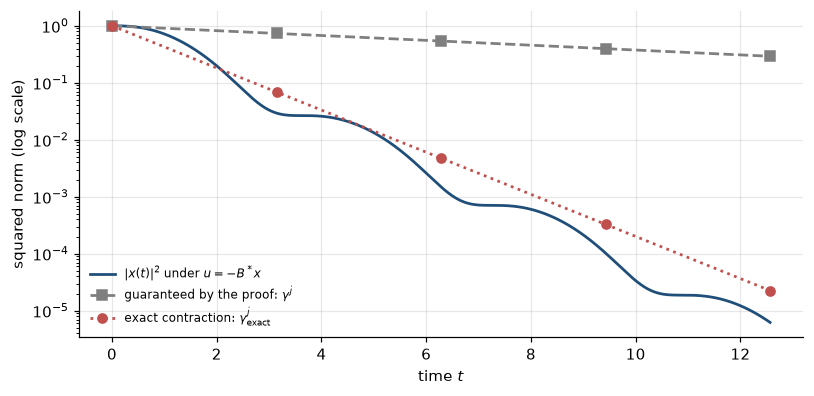

In [2]:
A, B = harmonic_oscillator()                 # E1: skew-adjoint A, controllable with one control
A_cl = A - B @ B.T                           # closed loop under u = -B^T x = -x2
T_period = np.pi

c0 = observability_constant(A, B, T_period, form="initial")
c_proof = 2 / c0 * (1 + 0.5 * np.linalg.norm(B, 2) ** 4 * T_period**2)
gamma_proof = 1 - 2 / c_proof
gamma_exact = np.linalg.norm(expm(A_cl * T_period), 2) ** 2
W = gramian(A_cl.T, B, T_period)             # int_0^T e^{A_cl^T t} B B^T e^{A_cl t} dt
print(f"observability constant c_0(T)         = {c0:.4f}")
print(f"proof: gamma = 1 - 2/c                = {gamma_proof:.4f}   -> rate of |x|^2 >= {abs(np.log(gamma_proof)) / T_period:.4f}")
print(f"exact contraction over one period     = {gamma_exact:.4e}   (1 - 2 lambda_min(W_T) = {1 - 2 * np.linalg.eigvalsh(W)[0]:.4e})")
print(f"true asymptotic rate of |x|^2         = {-2 * spectral_abscissa(A_cl):.4f}")

x0 = np.array([1.0, 0.0])
t = np.linspace(0, 4 * T_period, 800)
x = simulate(A_cl, B, lambda s: np.zeros(1), x0, t[-1], t)
j = np.arange(5)
fig, ax = plt.subplots(figsize=(7.5, 3.7))
ax.semilogy(t, np.sum(x**2, axis=1), color=COLORS["state"], label=r"$|x(t)|^2$ under $u=-B^*x$")
ax.semilogy(j * T_period, gamma_proof**j, "s--", color=COLORS["reference"], label=r"guaranteed by the proof: $\gamma^j$")
ax.semilogy(j * T_period, gamma_exact**j, "o:", color=COLORS["control"], label=r"exact contraction: $\gamma_{\rm exact}^j$")
ax.set_xlabel("time $t$"); ax.set_ylabel("squared norm (log scale)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Figure 1.** E1 under the feedback $u=-B^*x=-x_2$, from $x^0=(1,0)$. The squared norm $|x(t)|^2$ (solid), the decay guaranteed by the proof at multiples of the period $T=\pi$ (squares), and the exact worst-case contraction $\gamma_{\rm exact}^j$ (dots).

*Interpretation.* The theorem holds, but its constants are far from sharp. The proof guarantees a rate of about $0.1$ for $|x|^2$, while the optimal rate, $-2\max\operatorname{Re}\lambda(A-BB^*)$, is $1$. Both establish *exponential stability*; only the second is the *optimal decay rate*. At multiples of $T$ the solid curve lies below the dots, as it must: the dots are the worst case over all initial states, and $x^0=(1,0)$ is not the worst one. The proof is designed to prove *existence* of a rate from observability, which also works for PDEs where nothing can be computed explicitly. It is not designed to compute the best rate.

## 3. The damped oscillator inside the theory
`CORE`

The feedback of Theorem 1 is a damping. For E1, $B^*x=x_2$ is the velocity, so $u=-B^*x$ is the force $-x_2$. Scaling the actuator, $u=-kB^*x$ for any $k>0$, is the same theorem with $B$ replaced by $\sqrt k\,B$: **every positive damping stabilizes**. With mass, stiffness and damping the equation reads (pp. 129–130)
$$
m\,x_1''+k\,x_1'+R\,x_1=0,\qquad m,k,R>0,
$$
an applied force proportional to the velocity and of opposite sign. Its characteristic roots are
$$
r_\pm=\frac{-k\pm\sqrt{k^2-4mR}}{2m},\qquad
\max\operatorname{Re}r_\pm=\begin{cases}-\dfrac{k}{2m}, & k^2\le4mR,\\[6pt]
-\dfrac{k}{2m}+\sqrt{\dfrac{k^2}{4m^2}-\dfrac Rm}, & k^2\ge4mR .\end{cases}
$$

> **Remark on the source slides.** On p. 130 the overdamped real part is written $-\frac{k}{2m}\pm\sqrt{\frac{k^2}{4m}-\frac{R}{2m}}$. Dividing $\sqrt{k^2-4mR}$ by $2m$ gives $\sqrt{\frac{k^2}{4m^2}-\frac Rm}$, as above. The qualitative conclusion of the slide, the overdamping phenomenon, is unaffected.

Notebook 01 analyzed the case $m=R=1$ in full. The decay rate is largest at **critical damping** $k=2\sqrt{mR}$, and it tends to $0$ as $k\to\infty$. *Contradicting a first intuition, the decay rate does not increase indefinitely with the damping* (p. 130).

**Why there is a ceiling: a one-line explanation** *(pedagogical addition)*. With velocity feedback only, the characteristic polynomial is $m\lambda^2+k\lambda+R$. By Vieta's formulas the **product of the roots is $R/m$, whatever $k$**. As long as the roots are complex they lie on the circle $|\lambda|=\sqrt{R/m}$, with decay rate $k/(2m)$ growing with $k$. They meet at $-\sqrt{R/m}$ when $k=2\sqrt{mR}$. Beyond that they are real with a fixed product: if one moves to $-\infty$, the other must approach $0$. *A single feedback gain cannot move both roots far to the left.*

> **Predict.** If damping is good, should twice as much damping always be better? Look again at $k=4$ versus $k=8$ for E1, and predict where the two roots go in the complex plane as $k$ grows.

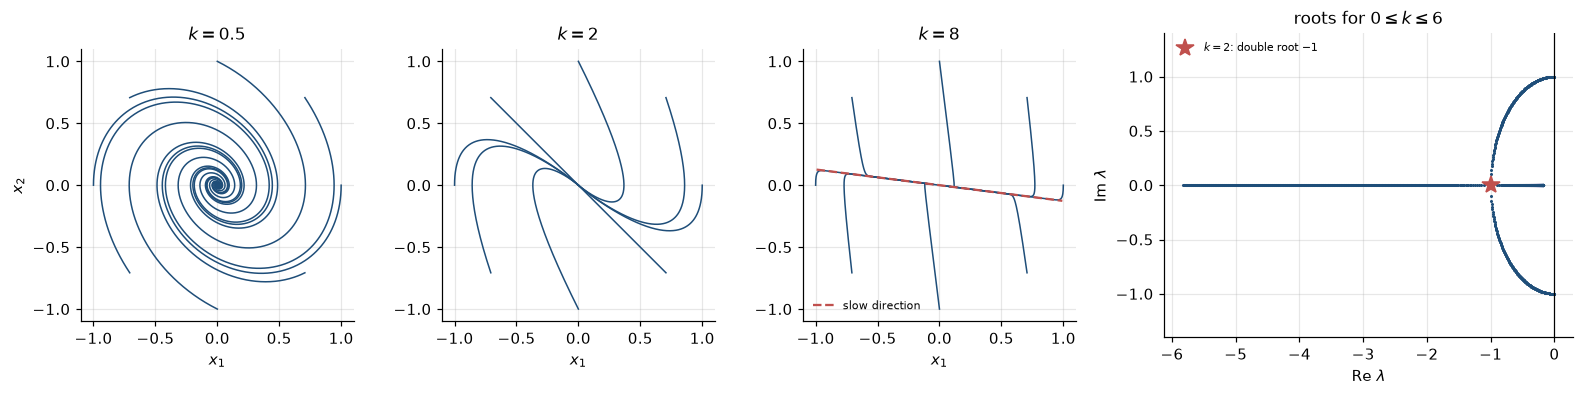

k = 0.5 (underdamped): roots [-0.25+0.9682j -0.25-0.9682j],  spectral rate 0.2500,  fitted slope on [10, 20] 0.2561
k =   2 (critical   ): roots [-1. -1.],  spectral rate 1.0000,  fitted slope on [10, 20] 0.9341
k =   8 (overdamped ): roots [-7.873 -0.127],  spectral rate 0.1270,  fitted slope on [10, 20] 0.1270


In [3]:
ks_phase = [0.5, 2.0, 8.0]
t_long = np.linspace(0, 20, 2000)
fig, axes = plt.subplots(1, 4, figsize=(14.5, 3.7), gridspec_kw={"width_ratios": [1, 1, 1, 1.5]})
for ax, k in zip(axes[:3], ks_phase):
    A_k, _ = damped_oscillator(k)
    for angle in np.linspace(0, 2 * np.pi, 8, endpoint=False):
        x_k = simulate(A_k, B, lambda s: np.zeros(1), [np.cos(angle), np.sin(angle)], 20, t_long)
        ax.plot(x_k[:, 0], x_k[:, 1], color=COLORS["state"], lw=1)
    if k > 2:                                   # slow eigendirection of the overdamped system
        lam_slow = (-k + np.sqrt(k * k - 4)) / 2
        v = np.array([1.0, lam_slow]) / np.hypot(1.0, lam_slow)
        ax.plot([-v[0], v[0]], [-v[1], v[1]], "--", color=COLORS["control"], lw=1.5, label="slow direction")
        ax.legend(fontsize=7, loc="lower left")
    ax.set_title(f"$k={k:g}$"); ax.set_xlabel("$x_1$"); ax.set_aspect("equal"); ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
axes[0].set_ylabel("$x_2$")

k_grid = np.linspace(0.0, 6.0, 601)
roots = np.array([np.roots([1.0, k, 1.0]) for k in k_grid])
axes[3].plot(roots[:, 0].real, roots[:, 0].imag, ".", ms=2, color=COLORS["state"])
axes[3].plot(roots[:, 1].real, roots[:, 1].imag, ".", ms=2, color=COLORS["state"])
axes[3].plot([-1], [0], "*", ms=12, color=COLORS["control"], label="$k=2$: double root $-1$")
axes[3].axvline(0, color="black", lw=0.8)
axes[3].set_xlabel(r"Re $\lambda$"); axes[3].set_ylabel(r"Im $\lambda$"); axes[3].set_title(r"roots for $0 \leq k \leq 6$")
axes[3].set_ylim(-1.4, 1.4); axes[3].legend(fontsize=7, loc="upper left")
plt.tight_layout(); plt.show()

# Reference: the exact spectral rate -max Re(root). Check: the slope of log|x(t)| fitted on the window [10, 20]
t_fit = np.linspace(10, 20, 201)
for k in ks_phase:
    A_k, _ = damped_oscillator(k)
    predicted = -np.roots([1.0, k, 1.0]).real.max()
    x_k = simulate(A_k, B, lambda s: np.zeros(1), [1.0, 0.0], 20, np.concatenate([[0.0], t_fit]))[1:]
    measured = -np.polyfit(t_fit, np.log(np.linalg.norm(x_k, axis=1)), 1)[0]
    regime = "underdamped" if k < 2 else ("critical" if k == 2 else "overdamped")
    print(f"k = {k:3g} ({regime:11s}): roots {np.round(np.roots([1.0, k, 1.0]), 4)},  spectral rate {predicted:.4f},  fitted slope on [10, 20] {measured:.4f}")

**Figure 2.** E1 under the feedback $u=-kx_2$. *First three panels:* phase portraits for $k=0.5$ (underdamped), $k=2$ (critical) and $k=8$ (overdamped), from eight initial states on the unit circle. For $k=8$ the dashed line is the eigendirection of the slow root. *Right:* the roots of $\lambda^2+k\lambda+1$ for $0\le k\le6$.

*Interpretation (answer to the prediction).* For small $k$ the trajectories spiral slowly: the roots sit on the unit circle (product $1$) and move left as $k$ grows. At $k=2$ they collide at $-1$. Beyond, one root runs to $-\infty$ while the other creeps back towards $0$. In the phase portrait for $k=8$, every trajectory is first pushed quickly onto the slow direction and then crawls along it to the origin. Twice as much damping is better only below $k=2$. The rates are the spectral ones, $-\max\operatorname{Re}\lambda=0.25$, $1$, $0.127$; the fitted slopes are only a check. At $k=2$ the prefactor $t$ of $(c_1+c_2t)e^{-t}$ biases the finite-window slope low ($0.93$).

## 4. Full-state feedback: pole placement
`CORE`

Theorem 1 assumed $A$ skew-adjoint. The property holds for every matrix (p. 131):

> **Theorem 2 (pole placement; p. 131).**
> *Assumption:* $(A,B)$ is controllable.
> *Conclusion:* for any prescribed complex numbers $\lambda_1,\dots,\lambda_n$, with non-real ones in conjugate pairs, there is a feedback matrix $L$ such that the eigenvalues of $A+BL$ are exactly $\lambda_1,\dots,\lambda_n$. In particular, the decay rate can be made arbitrarily fast.
> *Interpretation:* this does not contradict overdamping. The slides add that *all components of the state must be used in the feedback law* (p. 131). This is not a universal necessity for every controllable system: the theorem allows feedback on the full state, and whether every component is needed depends on the system. For E1 it is: velocity feedback alone leaves the product of the roots fixed (below), and the position gain is what moves it.

The slides state the theorem without proof. For E1 it can be done by hand *(pedagogical addition)*. With $u=-\ell_1x_1-\ell_2x_2$ the closed-loop matrix is $\begin{pmatrix}0&1\\-(1+\ell_1)&-\ell_2\end{pmatrix}$, with characteristic polynomial $\lambda^2+\ell_2\lambda+(1+\ell_1)$. To get roots $p_1,p_2$ we need
$$
\ell_2=-(p_1+p_2),\qquad\ell_1=p_1p_2-1 .
$$
The position gain $\ell_1$ is precisely what changes the product of the roots, the quantity that velocity feedback could not touch.

> **Predict.** With full-state feedback placing both poles at $-2$, or at $-4$, the decay is faster than the best damping. What do you expect to pay for it?

velocity only, k = 2 (best damping)    gains L = [ 0. -2.],  eigenvalues [-1. -1.],  fitted slope on [3, 6] 0.80,  max|u| = 0.74
full state, poles at -2                gains L = [-3. -4.],  eigenvalues [-2. -2.],  fitted slope on [3, 6] 1.78,  max|u| = 3.00
full state, poles at -4                gains L = [-15.  -8.],  eigenvalues [-4. -4.],  fitted slope on [3, 6] 3.77,  max|u| = 15.00


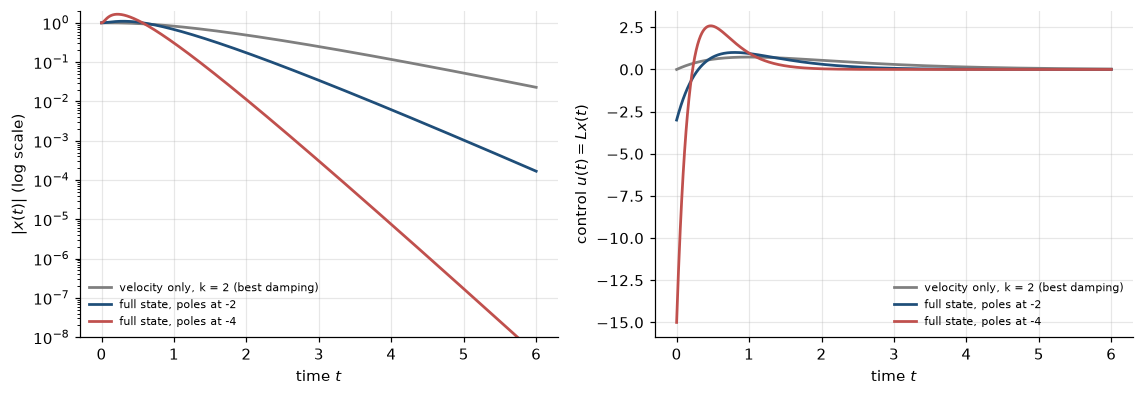

In [4]:
def full_state_gains(p1, p2):
    # u = -l1 x1 - l2 x2 gives the characteristic polynomial lambda^2 + l2 lambda + (1 + l1)
    return p1 * p2 - 1.0, -(p1 + p2)

designs = {"velocity only, k = 2 (best damping)": np.array([[0.0, -2.0]])}
for p in (-2.0, -4.0):
    l1, l2 = full_state_gains(p, p)
    designs[f"full state, poles at {p:g}"] = np.array([[-l1, -l2]])

t_short = np.linspace(0, 6, 1200)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.7))
for (name, L), color in zip(designs.items(), (COLORS["reference"], COLORS["state"], COLORS["control"])):
    eig = np.linalg.eigvals(A + B @ L)
    x_L = simulate(A + B @ L, B, lambda s: np.zeros(1), x0, t_short[-1], t_short)
    u_L = x_L @ L.T
    ax1.semilogy(t_short, np.linalg.norm(x_L, axis=1) + 1e-300, color=color, label=name)
    ax2.plot(t_short, u_L[:, 0], color=color, label=name)
    late = t_short > 3
    fitted = -np.polyfit(t_short[late], np.log(np.linalg.norm(x_L[late], axis=1)), 1)[0]
    print(f"{name:38s} gains L = {L.ravel()},  eigenvalues {np.real_if_close(np.round(eig, 6))},  "
          f"fitted slope on [3, 6] {fitted:.2f},  max|u| = {np.abs(u_L).max():.2f}")
ax1.set_ylim(1e-8, 2); ax1.set_xlabel("time $t$"); ax1.set_ylabel("$|x(t)|$ (log scale)"); ax1.legend(fontsize=7)
ax2.set_xlabel("time $t$"); ax2.set_ylabel("control $u(t)=Lx(t)$"); ax2.legend(fontsize=7)
plt.tight_layout(); plt.show()

**Figure 3.** E1 from $x^0=(1,0)$ under three feedback laws: the best velocity feedback ($k=2$, double pole at $-1$), and full-state feedback placing a double pole at $-2$ and at $-4$. *Left:* $|x(t)|$ on a logarithmic scale. *Right:* the control $u(t)=Lx(t)$.

*Interpretation (answer to the prediction).* Full-state feedback beats critical damping, and the rate is set by the chosen poles: exactly $1$, $2$ and $4$. The slopes fitted on $[3,6]$ ($0.80$, $1.78$, $3.77$) are biased low by the factor $t$ of each double pole. The price is the gain. Placing the poles at $-4$ needs gains $(15,8)$ and a peak control $|u|=15$, about twenty times the peak $0.74$ of the best damping; the norm $|x(t)|$ even grows at first before it decays. Large gains amplify any error in the measured state (notebook 01, Exercise 3). And, as H. R. Hall remarked about governors, a regulator should diminish fluctuations, not try to remove them altogether (p. 16). Fast is not free.

## 5. Controllability is not stabilizability
`CORE`

Theorems 1–2 *assume* controllability. Is it necessary for stabilization? No, and the recurring example E2 shows why. At $\varepsilon=0$,
$$
A=\begin{pmatrix}0&1&0\\-1&0&0\\0&0&-1\end{pmatrix},\qquad B_0=\begin{pmatrix}0\\1\\0\end{pmatrix},
$$
the pair is **not controllable** (notebook 02, §8): the input never reaches $x_3$. But that mode decays by itself, $x_3'=-x_3$. The feedback $u=-B_0^*x$ damps the oscillator, and the closed loop has eigenvalues $(-1\pm i\sqrt3)/2$ and $-1$: **E2 at $\varepsilon=0$ is stabilizable**.

By contrast, if the uncontrollable mode were unstable, say $x_3'=+x_3$, no feedback whatsoever could stabilize the system. The equation for $x_3$ does not involve $u$, so the eigenvalue $+1$ stays in the spectrum of $A+B_0L$ for every $L$ .

**The general statement in finite dimension** *(pedagogical addition, stated without proof)*. The reachable subspace $\mathcal R=\operatorname{Range}[B,AB,\dots,A^{n-1}B]$ is invariant under $A$, and under $A+BL$ for every $L$. The eigenvalues of the map that $A$ induces on the quotient $\mathbb R^n/\mathcal R$, the **uncontrollable modes**, remain eigenvalues of $A+BL$ whatever $L$ is. The pair $(A,B)$ is **stabilizable** if and only if every uncontrollable mode has negative real part. Controllability, $\mathcal R=\mathbb R^n$, is the case with no uncontrollable mode at all. For E2 at $\varepsilon=0$, $\mathcal R=\operatorname{span}\{e_1,e_2\}$ and the only uncontrollable mode is $-1$.

So controllability ≠ stabilizability. Controllability is sufficient for stabilization, and it allows every rate (Theorem 2). Stabilizability only asks that the modes the input cannot reach decay on their own.

In [5]:
A2, B2 = near_uncontrollable_system(0.0)
print("E2 at eps = 0: Kalman rank", kalman_rank(A2, B2), "of 3")
print("closed-loop eigenvalues with u = -B0^T x:", np.round(np.linalg.eigvals(A2 - B2 @ B2.T), 6))

A2_unstable = A2.copy(); A2_unstable[2, 2] = 1.0           # the uncontrollable mode made unstable
L_try = np.array([[-3.0, -5.0, 7.0]])                        # any feedback whatsoever
print("unstable variant, closed-loop eigenvalues for an arbitrary L:", np.round(np.linalg.eigvals(A2_unstable + B2 @ L_try), 6))

E2 at eps = 0: Kalman rank 2 of 3
closed-loop eigenvalues with u = -B0^T x: [-0.5+0.86603j -0.5-0.86603j -1. +0.j     ]
unstable variant, closed-loop eigenvalues for an arbitrary L: [-1.+0.j -4.+0.j  1.+0.j]


## 6. Control ↔ ML: damping and momentum
`CORE` · **MATHEMATICAL ANALOGY**

Gradient descent with **momentum** is described in the slides as a heavy ball rolling down the loss landscape (p. 286). Its continuous-time model is a damped second-order equation in which the gradient of the loss plays the role of the spring. The overdamping lesson of this notebook, too little damping oscillates and too much creeps, reappears there as the problem of choosing the momentum parameter. The analogy is structural, not an identity. Feedback stabilization designs the damping of a given physical system, whereas a momentum method chooses a parameter of an optimization algorithm whose "spring" is a loss landscape. Its mathematics belongs to [notebook 11](11_optimization_algorithms_ml.ipynb).

## 7. The estimate for $y$, with explicit constants
`DEEPER LOOK`

We prove $\int_0^T|B^*y|^2\le\tfrac12\|B\|^4T^2\int_0^T|B^*x|^2$ for $y'=Ay-BB^*x$, $y(0)=0$, with $A^*=-A$. Since $\langle Ay,y\rangle=0$,
$$
\frac12\frac{d}{dt}|y|^2=-\langle B^*x,B^*y\rangle\le|B^*x|\,\|B\|\,|y| .
$$
Hence $\frac{d}{dt}|y|\le\|B\|\,|B^*x|$ wherever $y\ne0$. Rigorously, apply the same computation to $\sqrt{|y|^2+\delta^2}$ and let $\delta\to0$. Integrating, and using Cauchy–Schwarz,
$$
|y(t)|\le\|B\|\int_0^t|B^*x|\,ds\le\|B\|\,\sqrt t\,\Big(\int_0^T|B^*x|^2\Big)^{1/2}.
$$
Therefore
$$
\int_0^T|B^*y|^2\le\|B\|^2\int_0^T|y|^2\le\|B\|^4\Big(\int_0^Tt\,dt\Big)\int_0^T|B^*x|^2=\tfrac12\|B\|^4T^2\int_0^T|B^*x|^2 .
$$

> **Remark on the source slides.** On p. 128 the corresponding estimate is obtained through Gronwall's inequality, and the printed constants mix $|B|$ and $|B^*|$ and include a factor $e^T$. The argument above avoids Gronwall altogether, because $A$ is skew-adjoint. It gives the constant used in §2; any valid constant suffices for the theorem.

## 8. Common misconceptions
`CORE`

**"More damping is always better."** Only up to critical damping. Velocity feedback cannot change the product of the characteristic roots (§3).

**"Pole placement contradicts overdamping."** It uses *all* state components. Velocity feedback alone is limited; full-state feedback is not (§4).

**"Feedback can bring the state exactly to rest at a chosen time."** Not with an autonomous linear feedback: its solutions never vanish in finite time from $x^0\ne0$ (§1). Exact steering in finite time is an open-loop task (notebooks 02–04).

**"Uncontrollable means unstabilizable."** E2 at $\varepsilon=0$ is uncontrollable but stabilizable, because its unreachable mode is stable (§5).

**"The rate in the proof of Theorem 1 is the actual rate."** It is a guaranteed lower bound, far from sharp (Figure 1).

## 9. What you should remember
`CORE`

1. Stabilization: find $L$ with $|x(t)|\le ce^{-\omega t}|x^0|$ for $x'=(A+BL)x$. An autonomous linear feedback decays exponentially, but never reaches $0$ in finite time from $x^0\ne0$.
2. For $A^*=-A$ and $(A,B)$ controllable, $u=-B^*x$ stabilizes: energy identity $+$ observability ⇒ contraction over one period ⇒ exponential decay.
3. The rate guaranteed by the proof is valid but pessimistic.
4. Damping $u=-kx_2$ is this feedback. Velocity feedback fixes the product of the roots, which is why the decay rate peaks at critical damping $k=2\sqrt{mR}$.
5. Full-state feedback places the poles anywhere (Theorem 2), at the price of large gains.
6. Controllability is sufficient but not necessary for stabilization: stabilizability requires only that the uncontrollable modes be stable.

## 10. Exercises

★ conceptual · ★★ mathematical · ★★★ computational. `FIRST PASS` exercises are the minimum route; `STANDARD` ones consolidate the notebook; `ADVANCED` ones are optional. Reference solutions are kept in a separate instructor notebook. Try first.

**Exercise 1 ★ (position feedback)** · `FIRST PASS`. Can the oscillator E1 be stabilized by feedback on the *position* only, $u=-\ell x_1$? Answer from the characteristic polynomial, and interpret physically.

**Exercise 2 ★★ (what velocity feedback cannot do)** · `FIRST PASS`. For E1, show that no velocity feedback $u=-kx_2$ can place both closed-loop poles at $-2$, and that full-state feedback can. Compute the gains for poles $p_1=-1$, $p_2=-3$, and check them numerically.

**Exercise 3 ★★ (a spectral proof of Theorem 1)** · `STANDARD`. Let $A^*=-A$ and $(A,B)$ controllable. (a) Show that every eigenvalue $\lambda$ of $A-BB^*$ satisfies $\operatorname{Re}\lambda\le0$. *Hint:* compute $v^*(A-BB^*)v$ for an eigenvector $v$. (b) Show that $\operatorname{Re}\lambda=0$ would force $B^*v=0$ and $Av=\lambda v$, and that this contradicts the Kalman condition. (c) Deduce Theorem 1 in finite dimension. Why does this argument not extend to PDEs, while the proof of §2 does?

**Exercise 4 ★★ (the unstable uncontrollable mode)** · `STANDARD`. For the unstable variant of E2 (§5), show that for *every* feedback matrix $L\in\mathbb R^{1\times3}$ the number $+1$ is an eigenvalue of $A+B_0L$. *Hint:* look at the third row of $A+B_0L$.

**Exercise 5 ★★★ (how sharp is the proof?)** · `ADVANCED`. For E1 under $u=-B^*x$, compute for $T\in[0.5,20]$ the exact contraction $\gamma_{\rm exact}(T)=\|e^{(A-BB^*)T}\|^2$ and the factor $\gamma(T)=1-2/c(T)$ guaranteed by the proof (§2), with $c(T)=\tfrac{2}{c_0(T)}\big(1+\tfrac12T^2\big)$. Plot the guaranteed rates $|\ln\gamma(T)|/T$ and $|\ln\gamma_{\rm exact}(T)|/T$ against $T$. Which $T$ gives the best guaranteed rate, and how far is it from the true rate $1$?

In [6]:
# TODO: student exercise (Exercise 5)
# For T on a grid in [0.5, 20], compute c0(T) with observability_constant(A, B, T), the proof's
# gamma(T) = 1 - 2/c(T), and gamma_exact(T) = ||expm(A_cl T)||_2^2; plot |ln gamma|/T for both.

def guaranteed_rate(T_):
    ...  # your code here
    return None

## Where are we going?
`CORE`

This closes Part I. Every control in notebooks 02–05 came from a **minimization principle** (HUM, $J_{bb}$, $J_{sw}$) or from an **energy identity** (feedback). [Notebook 06](06_variational_principles_gradient_flows.ipynb) studies these two ideas in their own right: when a minimizer exists, and how following the gradient, a gradient flow and its discretization, gradient descent, finds it. Its Lyapunov function plays the role of the energy here, and the same mechanism will later become the training of learning machines.

## Source map
`CORE`

All page numbers are PDF pages of `CML_slides_20250520.pdf`; the machine-readable version is `source_map.csv`.

| Section | PDF pages | Content in the slides |
|---|---|---|
| §1 Stabilization problem | 121–123 | Open and closed loop; skew-adjoint $A$ and energy conservation; definition; no finite-time extinction |
| §2 Theorem 1 and proof | 123–128 | $L=-B^*$; energy identity; iteration and constants; decomposition and observability |
| §3 Damped oscillator | 129–130, 23–24 | $mx''+Rx+kx'=0$; roots; overdamping |
| §4 Pole placement | 131 | Arbitrary decay rate; all state components needed |
| §4 Fluctuations | 16 | Hall's remark on governors |
| §6 Momentum | 286 | Heavy ball |
| §7 Estimate for $y$ | 128 | Gronwall-based estimate (replaced) |

The source-map rows also record the pedagogical additions (Figure 1 and the exact contraction, the Vieta explanation and Figure 2, the 2-D pole-placement formulas and Figure 3, stabilizability and the unstable variant of E2) and the corrections (p. 130 root formula; p. 128 constants).